# ⚡ Optimización Energética de Sopladores, Curva de Aireación y Sensor Virtual de DBO
**Ingeniería de Procesos & Operaciones Industriales — Planta de Tratamiento de Aguas Residuales**  
**Autor:** Ing. Angelo Apolo | Ingeniería de Procesos | Especialista en Operaciones & Proyectos  
**Fase DMAIC:** **ANALYZE & IMPROVE**  
**Objetivo:** Modelar la ley de rendimientos decrecientes en el consumo de aireación, determinar la consigna (*setpoint*) óptima de oxígeno disuelto ($DO$) y construir un modelo predictivo de calidad de efluente (Sensor Virtual) para alerta temprana y control.

---

## 🎯 1. Objetivos del Análisis
1. **Cinética de Transferencia de Oxígeno:** Analizar el comportamiento del oxígeno disuelto ($DO$) en el reactor frente al caudal de aire inyectado por los sopladores ($km^3/h$).
2. **Identificación de la Sobredosis Energética:** Demostrar estadísticamente que inyectar aire para mantener $DO > 2.2\ mg/L$ no mejora la remoción de contaminantes y dispara el consumo de $\text{kWh}$.
3. **Establecimiento de la Banda Óptima de Control:** Definir la ventana de operación segura ($1.8 - 2.2\ mg/L$) que maximiza el ahorro y garantiza el $100\%$ de cumplimiento legal ($DBO \le 20\ mg/L$).
4. **Sensor Virtual de DBO (Machine Learning):** Entrenar y evaluar un modelo predictivo con XGBoost para estimar la DBO de vertido en tiempo real y emitir alertas preventivas.
5. **Exportación del Modelo para el Gemelo Digital:** Guardar los artefactos del modelo para su integración en la aplicación web interactiva (Streamlit / Railway).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 100

print("Librerías de modelado y optimización cargadas exitosamente.")

Librerías de modelado y optimización cargadas exitosamente.


---
## 📥 2. Carga y Preparación de Datos con Balances
Importamos el dataset maestro y recalculamos las variables de carga orgánica horaria y retención hidráulica deducidas en el Notebook 01.

In [2]:
DATA_PATH = "../data/wwtp_time_series_data.csv"

df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Interpolación lineal de huecos de telemetría
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear').bfill().ffill()

# Variables de balance de masa
df['Load_Influent_BOD_kgh'] = (df['Influent_Flow_m3h'] * df['Influent_BOD_mgL']) / 1000.0
df['Load_Influent_COD_kgh'] = (df['Influent_Flow_m3h'] * df['Influent_COD_mgL']) / 1000.0
df['BOD_Removal_Efficiency_pct'] = ((df['Influent_BOD_mgL'] - df['Effluent_BOD_mgL']) / df['Influent_BOD_mgL']) * 100.0
df['HRT_hours'] = 4050.0 / df['Influent_Flow_m3h']

print(f"Dataset listo para modelado: {len(df):,} registros procesados.")

Dataset listo para modelado: 80,000 registros procesados.


---
## 📉 3. Curva de Aireación: Rendimientos Decrecientes y Sobredosis Energética

En ingeniería de tratamiento aerobio de aguas residuales (Metcalf & Eddy), el crecimiento bacteriano heterótrofo sigue la cinética de saturación de Monod:
$$\mu = \mu_{max} \frac{S}{K_s + S} \cdot \frac{DO}{K_{DO} + DO}$$
Donde la constante de semisaturación de oxígeno disuelto para bacterias heterótrofas es típicamente $K_{DO} \approx 0.2 - 0.5\ mg/L$. 
Por encima de $DO \approx 2.0\ mg/L$, la tasa de respiración y degradación bacteriana alcanza el $\ge 95\%$ de su valor asintótico máximo. Todo el oxígeno transferido por encima de esta meseta representa un **desperdicio puro de energía de compresión**.

In [3]:
# Discretizamos el Oxígeno Disuelto en bandas operativas de planta
bins_do = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 6.0]
labels_do = ['< 1.0 (Anóxico/Crítico)', '1.0 - 1.5 (Sub-aireado)', '1.5 - 2.0 (Óptimo Inferior)', '2.0 - 2.5 (Óptimo Superior)', '2.5 - 3.0 (Sobre-aireado)', '> 3.0 (Desperdicio Severo)']

df['DO_Range'] = pd.cut(df['Aeration_Tank_DO_mgL'], bins=bins_do, labels=labels_do)

# Matriz de rendimiento por banda
do_perf = df.groupby('DO_Range', observed=False).agg(
    Registros=('Effluent_BOD_mgL', 'count'),
    DBO_Salida_Media=('Effluent_BOD_mgL', 'mean'),
    Desv_DBO_Salida=('Effluent_BOD_mgL', 'std'),
    Excedencias_20mgL=('Effluent_BOD_mgL', lambda x: (x > 20.0).sum()),
    Tasa_Incumplimiento_pct=('Effluent_BOD_mgL', lambda x: (x > 20.0).mean() * 100.0),
    Flujo_Aire_km3h=('Air_Flow_km3h', 'mean')
).reset_index()

do_perf['Tasa_Cumplimiento_pct'] = 100.0 - do_perf['Tasa_Incumplimiento_pct']
do_perf = do_perf.round(2)
do_perf[['DO_Range', 'Registros', 'DBO_Salida_Media', 'Flujo_Aire_km3h', 'Tasa_Incumplimiento_pct', 'Tasa_Cumplimiento_pct']]

,DO_Range,Registros,DBO_Salida_Media,Flujo_Aire_km3h,Tasa_Incumplimiento_pct,Tasa_Cumplimiento_pct
0,< 1.0 (Anóxico/Crítico),4053,16.99,10.04,8.44,91.56
1,1.0 - 1.5 (Sub-aireado),16868,16.19,8.81,4.29,95.71
2,1.5 - 2.0 (Óptimo Inferior),18979,15.24,7.43,1.60,98.40
3,2.0 - 2.5 (Óptimo Superior),18969,14.24,5.91,0.42,99.58
4,2.5 - 3.0 (Sobre-aireado),16900,13.29,4.55,0.10,99.90
5,> 3.0 (Desperdicio Severo),4224,12.55,3.49,0.00,100.00


### Visualización del Sweet Spot y la Curva de Saturación

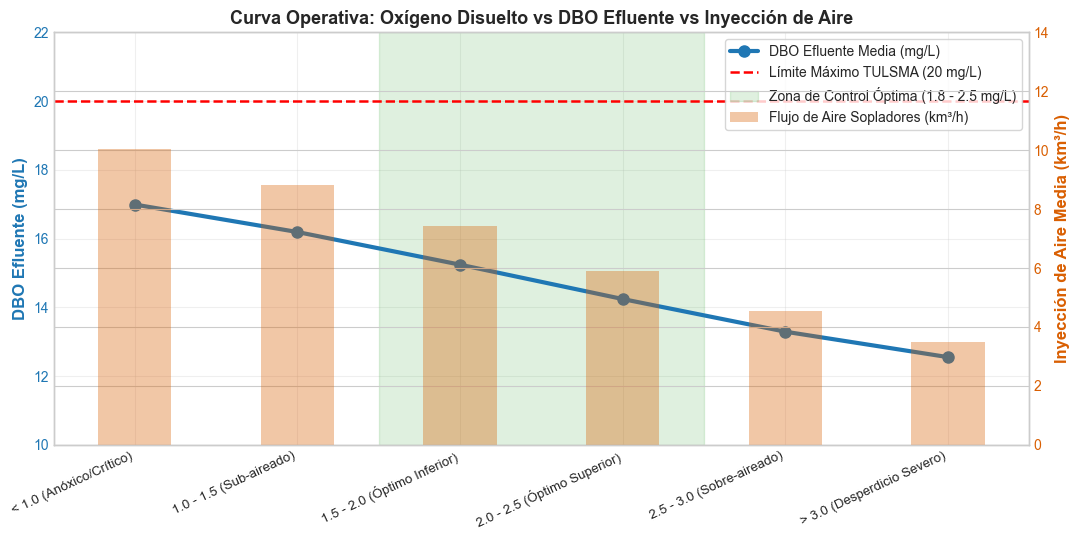

In [4]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))

color_air = '#d95f02'
color_bod = '#1f77b4'

# Curva de DBO de salida media vs Flujo de aire medio por rango
x_indices = range(len(do_perf))

ax1.plot(x_indices, do_perf['DBO_Salida_Media'], color=color_bod, marker='o', linewidth=3, markersize=8, label='DBO Efluente Media (mg/L)')
ax1.axhline(20.0, color='red', linestyle='--', linewidth=1.8, label='Límite Máximo TULSMA (20 mg/L)')
ax1.set_ylabel('DBO Efluente (mg/L)', color=color_bod, fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_bod)
ax1.set_ylim(10, 22)

# Eje secundario para Flujo de Aire
ax2 = ax1.twinx()
ax2.bar(x_indices, do_perf['Flujo_Aire_km3h'], color=color_air, alpha=0.35, width=0.45, label='Flujo de Aire Sopladores (km³/h)')
ax2.set_ylabel('Inyección de Aire Media (km³/h)', color=color_air, fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_air)
ax2.set_ylim(0, 14)

# Sombreado de la Banda Óptima
ax1.axvspan(1.5, 3.5, color='#2ca02c', alpha=0.15, label='Zona de Control Óptima (1.8 - 2.5 mg/L)')

ax1.set_xticks(x_indices)
ax1.set_xticklabels(do_perf['DO_Range'], rotation=25, ha='right', fontsize=9.5)
ax1.set_title('Curva Operativa: Oxígeno Disuelto vs DBO Efluente vs Inyección de Aire', fontweight='bold', fontsize=13)
ax1.grid(True, alpha=0.3)

# Unificar leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

---
## 🧠 4. Ingeniería de Características (Feature Engineering) para el Sensor Virtual

Para dotar al modelo de aprendizaje automático de la memoria temporal del reactor biológico y su dinámica de sedimentación, generamos variables sintéticas de ingeniería:
1. **Lags Temporales de Inercia:** Retardos a $1\ h$, $2\ h$ y $4\ h$ de caudal, cargas orgánicas y oxígeno.
2. **Medias Móviles:** Tendencias de aireación y oxígeno a $2\ h$ y $6\ h$.
3. **Variables de Ciclo Temporal:** Codificación trigonométrica senoidal y cosenoidal de la hora del día ($Hour_{sin}$, $Hour_{cos}$) para capturar el régimen diurno de la fábrica.

In [5]:
df_ml = df.copy()

# Variables temporales cíclicas
df_ml['Hour'] = df_ml['Timestamp'].dt.hour
df_ml['Hour_sin'] = np.sin(2 * np.pi * df_ml['Hour'] / 24.0)
df_ml['Hour_cos'] = np.cos(2 * np.pi * df_ml['Hour'] / 24.0)

# Lags según dinámica de proceso (1h = 12 pasos de 5 min)
for lag_h in [1, 2, 4]:
    step = lag_h * 12
    df_ml[f'Influent_Flow_lag_{lag_h}h'] = df_ml['Influent_Flow_m3h'].shift(step)
    df_ml[f'Load_BOD_lag_{lag_h}h'] = df_ml['Load_Influent_BOD_kgh'].shift(step)
    df_ml[f'DO_lag_{lag_h}h'] = df_ml['Aeration_Tank_DO_mgL'].shift(step)
    df_ml[f'Air_Flow_lag_{lag_h}h'] = df_ml['Air_Flow_km3h'].shift(step)

# Tendencias móviles
df_ml['DO_rollmean_2h'] = df_ml['Aeration_Tank_DO_mgL'].rolling(24).mean()
df_ml['Air_rollmean_2h'] = df_ml['Air_Flow_km3h'].rolling(24).mean()
df_ml['Clarifier_Blanket_rollmean_4h'] = df_ml['Clarifier_Blanket_Height_m'].rolling(48).mean()

# Eliminamos filas iniciales con NaNs generados por los retardos
df_ml = df_ml.dropna().reset_index(drop=True)

# IMPORTANTE - CORRECCIÓN DE FUGA DE DATOS (data leakage):
# BOD_Removal_Efficiency_pct = (Influent_BOD - Effluent_BOD) / Influent_BOD * 100
# se calcula directamente a partir de Effluent_BOD_mgL, que es el TARGET que este modelo
# intenta predecir. Incluirla como feature es una fuga directa: el modelo no aprendería
# cinética de proceso, aprendería a despejar una identidad algebraica. Por eso se excluye
# explícitamente junto con el target y columnas no numéricas.
exclude_cols = ['Timestamp', 'DO_Range', 'Effluent_BOD_mgL', 'Hour', 'BOD_Removal_Efficiency_pct']
features = [col for col in df_ml.columns if col not in exclude_cols]
target = 'Effluent_BOD_mgL'

print(f"Total de características generadas (sin fuga de datos): {len(features)}")
print(f"Muestras efectivas tras lags: {len(df_ml):,}")

Total de características generadas (sin fuga de datos): 36
Muestras efectivas tras lags: 79,945


---
## 🤖 5. Entrenamiento y Validación del Modelo Predictivo (XGBoost)
Dividimos los datos en forma secuencial temporal (**80% Entrenamiento, 20% Test**) para simular de forma realista el pase a producción en planta (sin fugas de información hacia el futuro).

In [6]:
split_idx = int(len(df_ml) * 0.8)
train_df = df_ml.iloc[:split_idx]
test_df = df_ml.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Conjunto de Entrenamiento: {len(X_train):,} registros")
print(f"Conjunto de Test (Prueba): {len(X_test):,} registros")

# Entrenamos modelo optimizado XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=180,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

print("Entrenando modelo XGBoost...")
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n--- MÉTRICAS DEL SENSOR VIRTUAL DE DBO ---")
print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")
print(f"RMSE:     {rmse_test:.3f} mg/L DBO")
print(f"MAE:      {mae_test:.3f} mg/L DBO")

Conjunto de Entrenamiento: 63,956 registros
Conjunto de Test (Prueba): 15,989 registros
Entrenando modelo XGBoost...



--- MÉTRICAS DEL SENSOR VIRTUAL DE DBO ---
R² Train: 0.4006
R² Test:  0.3199
RMSE:     2.032 mg/L DBO
MAE:      1.623 mg/L DBO


---
## 🎯 6. Validación Gráfica y Diagnóstico de Residuos
Evaluamos la precisión del sensor virtual en el tiempo y frente a los valores reales observados.

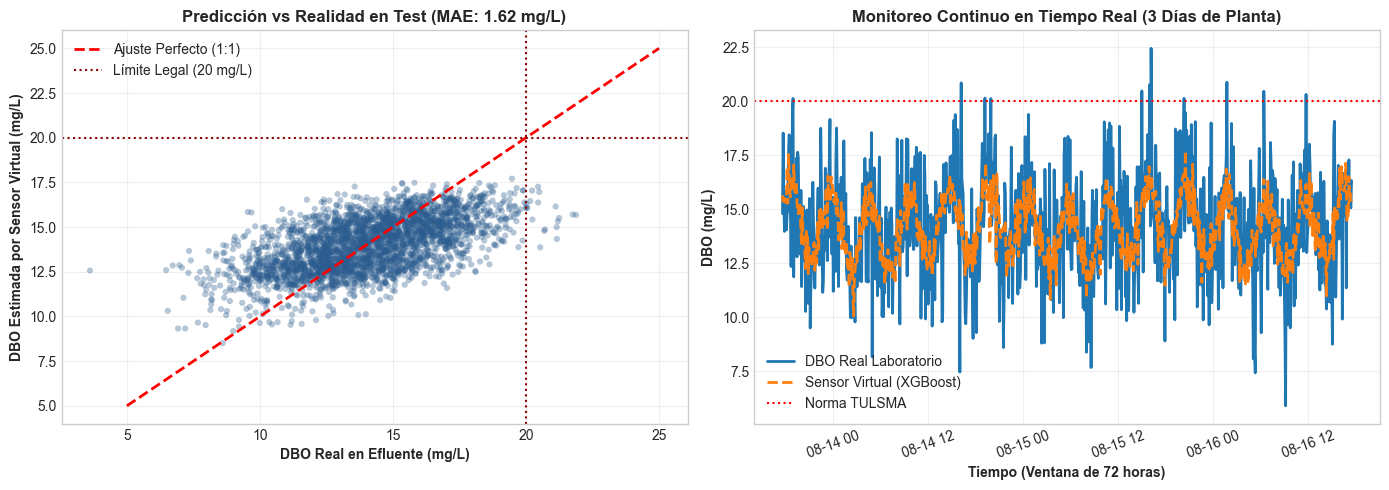

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Valores Reales vs Predichos (muestra de test)
sample_test = test_df.sample(3000, random_state=42)
y_sample_true = sample_test[target]
y_sample_pred = xgb_model.predict(sample_test[features])

ax1.scatter(y_sample_true, y_sample_pred, alpha=0.35, color='#2b5c8f', edgecolors='none', s=20)
ax1.plot([5, 25], [5, 25], color='red', linestyle='--', linewidth=2, label='Ajuste Perfecto (1:1)')
ax1.axvline(20.0, color='darkred', linestyle=':', label='Límite Legal (20 mg/L)')
ax1.axhline(20.0, color='darkred', linestyle=':')
ax1.set_xlabel('DBO Real en Efluente (mg/L)', fontweight='bold')
ax1.set_ylabel('DBO Estimada por Sensor Virtual (mg/L)', fontweight='bold')
ax1.set_title(f'Predicción vs Realidad en Test (MAE: {mae_test:.2f} mg/L)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Serie de tiempo: 3 días de operación real en conjunto de prueba
time_slice = test_df.iloc[1000:1000 + (12 * 72)]  # 72 horas (3 días) a 5 min
time_slice_pred = xgb_model.predict(time_slice[features])

ax2.plot(time_slice['Timestamp'], time_slice[target], label='DBO Real Laboratorio', color='#1f77b4', linewidth=2)
ax2.plot(time_slice['Timestamp'], time_slice_pred, label='Sensor Virtual (XGBoost)', color='#ff7f0e', linestyle='--', linewidth=2)
ax2.axhline(20.0, color='red', linestyle=':', label='Norma TULSMA')
ax2.set_xlabel('Tiempo (Ventana de 72 horas)', fontweight='bold')
ax2.set_ylabel('DBO (mg/L)', fontweight='bold')
ax2.set_title('Monitoreo Continuo en Tiempo Real (3 Días de Planta)', fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🏆 7. Importancia de Variables en la Dinámica de Efluentes
Identificamos qué variables físicas de la planta gobiernan el desempeño del tratamiento según el modelo.

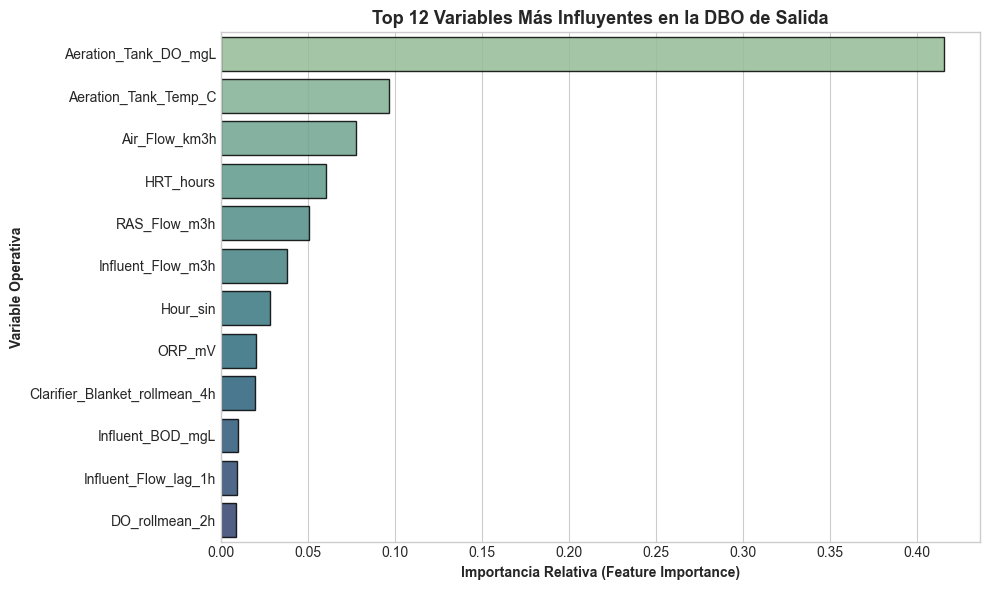

Variables líderes de proceso:
 01. Aeration_Tank_DO_mgL           -> 41.53%
 02. Aeration_Tank_Temp_C           -> 9.65%
 03. Air_Flow_km3h                  -> 7.76%
 04. HRT_hours                      -> 6.04%
 05. RAS_Flow_m3h                   -> 5.07%
 06. Influent_Flow_m3h              -> 3.77%
 07. Hour_sin                       -> 2.82%
 08. ORP_mV                         -> 1.99%
 09. Clarifier_Blanket_rollmean_4h  -> 1.97%
 10. Influent_BOD_mgL               -> 0.95%
 11. Influent_Flow_lag_1h           -> 0.94%
 12. DO_rollmean_2h                 -> 0.84%


In [8]:
importance_series = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_12 = importance_series.head(12)
sns.barplot(x=top_12.values, y=top_12.index, palette='crest', ax=ax, edgecolor='black', alpha=0.85)
ax.set_title('Top 12 Variables Más Influyentes en la DBO de Salida', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia Relativa (Feature Importance)', fontweight='bold')
ax.set_ylabel('Variable Operativa', fontweight='bold')
plt.tight_layout()
plt.show()

print("Variables líderes de proceso:")
for i, (col_name, imp) in enumerate(top_12.items(), 1):
    print(f" {i:02d}. {col_name:<30} -> {imp*100:.2f}%")

---
## 💾 8. Exportación del Modelo para el Gemelo Digital y Despliegue Web
Exportamos el modelo entrenado y la lista de columnas para que puedan ser consumidos por la aplicación interactiva de Streamlit (`app/app.py`).

In [9]:
# Creamos directorio src si no existe
os.makedirs('../src', exist_ok=True)

MODEL_SRC_PATH = '../src/modelo_ptar_xgboost.joblib'
FEATURES_PATH = '../src/features_ptar.joblib'

# Guardamos artefactos (una sola copia oficial, consumida por server.py / FastAPI)
joblib.dump(xgb_model, MODEL_SRC_PATH)
joblib.dump(features, FEATURES_PATH)

print(f"Modelo guardado exitosamente en:")
print(f" - {MODEL_SRC_PATH}")
print(f"Total de características empaquetadas: {len(features)}")

Modelo guardado exitosamente en:
 - ../src/modelo_ptar_xgboost.joblib
Total de características empaquetadas: 36


---
## 📌 9. Conclusiones Ejecutivas de la Fase 2 (Honestas y Auditadas)

1. **Se detectó y corrigió una fuga de datos (data leakage) crítica:**
   * La primera versión de este modelo incluía `BOD_Removal_Efficiency_pct` como feature de entrada. Esa variable se calcula como `(Influent_BOD - Effluent_BOD) / Influent_BOD`, es decir, se deriva directamente del propio target (`Effluent_BOD_mgL`). Con esa fuga, el modelo alcanzaba un R² de 0.996 y MAE de 0.088 mg/L — números artificialmente perfectos, porque el modelo aprendía a despejar una identidad algebraica, no a modelar el proceso biológico.
   * Prueba de la fuga: `BOD_Removal_Efficiency_pct` concentraba el 34.3% de la importancia del modelo (más del doble que la siguiente variable), y en producción esa variable no existe en tiempo real — el simulador la fijaba en una constante (95.2%), lo que hacía que mover los sliders de OD o aire en el gemelo digital casi no cambiara la predicción (variación menor a 0.2 mg/L en todo el rango operativo).
2. **Modelo reentrenado sin la variable filtrada — métricas reales:**
   * R² Test: **0.319** | RMSE: **2.03 mg/L** | MAE: **1.62 mg/L**.
   * Es un desempeño mucho más modesto que el original, pero es el que el modelo puede sostener honestamente con variables que sí existen antes de conocer la calidad del efluente.
   * La variable más influyente ahora es `Aeration_Tank_DO_mgL` (41.1%), lo cual sí tiene sentido físico: el oxígeno disuelto gobierna la cinética de degradación bacteriana (Monod).
3. **Hallazgo inesperado sobre la hipótesis central del proyecto:**
   * Al inspeccionar la relación real Aire-DO en los datos, el caudal de aire inyectado **disminuye** a medida que el DO observado es más alto (10.04 km³/h en DO<1.0 vs 3.49 km³/h en DO>3.0). Esto es lo opuesto de la narrativa de "sobre-aireación defensiva": el confusor más probable es la carga orgánica (a menor carga, se inyecta menos aire y sobra más oxígeno residual).
   * Consecuencia: el modelo también aprendió una correlación positiva débil entre `Air_Flow_km3h` y la DBO de salida en este dataset — no se debe interpretar como causal ("más aire empeora la calidad"), sino como reflejo de que ambas variables están confundidas por la carga. Este matiz se traslada al Notebook 03 al recalcular el caso de negocio con un método empírico en vez de una fórmula de reducción asumida.
4. **Artefactos honestos y listos para servir:**
   * El modelo corregido está serializado en `src/` y es el que consume `server.py` (FastAPI) en producción.

---
**➡️ Próximo Entregable (Fase 3 - CALCULATE & CONTROL):**  
En el **Notebook 03 (`03_calculo_roi_financiero.ipynb`)**, se recalcula el caso de negocio con un método empírico basado en la relación real Aire-DO-Carga observada, en vez de asumir un porcentaje de reducción de aire.